# LiH Single-Circuit VQE (HF -> Givens -> ZZ)

This notebook optimizes one fixed ansatz for the LiH active-8 Hamiltonian:
- HF reference preparation on qubits `0` and `4`
- Core Givens pairs: `(0,3)`, `(4,7)`, `(0,1)`, `(4,5)`, `(0,2)`, `(4,6)`
- ZZ pairs: `(0,4)`, `(0,3)`, `(4,7)`, `(0,7)`, `(3,4)`

Two optimizers are run independently and compared:
- Adam
- L-BFGS-B

In [1]:
import pickle
import sys
import time
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector, state_fidelity
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

In [2]:
# Hamiltonian loader (compatible with OpenFermion/Qiskit legacy pickle objects)
file_name = "LiH_active8_scan_bond_1.596_active_1-2-4-5_q8_of.pkl"

try:
    import google.colab
    in_colab = True
except Exception:
    in_colab = False

if in_colab:
    save_folder = Path("/content/drive/My Drive/Quantum_chemistry/pauli_Ham")
else:
    cwd = Path.cwd()
    local_candidates = [cwd / "Pauli_Ham", cwd.parent / "Pauli_Ham"]
    save_folder = next((p for p in local_candidates if p.exists()), local_candidates[0])

file_path = save_folder / file_name


class PauliSumOpShim:
    def __init__(self, *args, **kwargs):
        pass


def install_qiskit_opflow_shim() -> None:
    module_name = "qiskit.opflow.primitive_ops.pauli_sum_op"
    opflow_module = sys.modules.get("qiskit.opflow", types.ModuleType("qiskit.opflow"))
    primitive_ops_module = sys.modules.get(
        "qiskit.opflow.primitive_ops", types.ModuleType("qiskit.opflow.primitive_ops")
    )
    pauli_sum_op_module = sys.modules.get(module_name, types.ModuleType(module_name))
    pauli_sum_op_module.PauliSumOp = PauliSumOpShim

    sys.modules["qiskit.opflow"] = opflow_module
    sys.modules["qiskit.opflow.primitive_ops"] = primitive_ops_module
    sys.modules[module_name] = pauli_sum_op_module


def to_sparse_pauli_op(operator) -> SparsePauliOp:
    if hasattr(operator, "_primitive"):
        operator = operator._primitive

    if isinstance(operator, SparsePauliOp):
        return operator

    if hasattr(operator, "terms"):
        n_qubits = 0
        for term in operator.terms:
            for qubit_idx, _ in term:
                n_qubits = max(n_qubits, qubit_idx + 1)

        pauli_terms = []
        for term, coeff in operator.terms.items():
            label = ["I"] * n_qubits
            for qubit_idx, pauli in term:
                label[n_qubits - 1 - qubit_idx] = pauli
            pauli_terms.append(("".join(label), complex(coeff)))

        return SparsePauliOp.from_list(pauli_terms).simplify()

    raise TypeError(f"Unsupported Hamiltonian type: {type(operator)}")


if not file_path.exists():
    raise FileNotFoundError(f"Hamiltonian file not found: {file_path}")

install_qiskit_opflow_shim()
with file_path.open("rb") as f:
    H_qubit_loaded = to_sparse_pauli_op(pickle.load(f))

print("--- Hamiltonian Loaded Successfully ---")
print(f"Runtime: {'Google Colab' if in_colab else 'Local'}")
print(f"Folder: {save_folder}")
print(f"File: {file_name}")
print(f"Number of qubits: {H_qubit_loaded.num_qubits}")
print(f"Number of Pauli terms: {len(H_qubit_loaded)}")
print(f"Object type: {type(H_qubit_loaded)}")

--- Hamiltonian Loaded Successfully ---
Runtime: Local
Folder: /Users/zacharyhe/cross_chips_sim/Pauli_Ham
File: LiH_active8_scan_bond_1.596_active_1-2-4-5_q8_of.pkl
Number of qubits: 8
Number of Pauli terms: 193
Object type: <class 'qiskit.quantum_info.operators.symplectic.sparse_pauli_op.SparsePauliOp'>


Number of parameters: 8
Givens pairs: [(0, 3), (4, 7), (0, 1), (4, 5), (1, 3), (5, 7), (0, 2), (4, 6)]


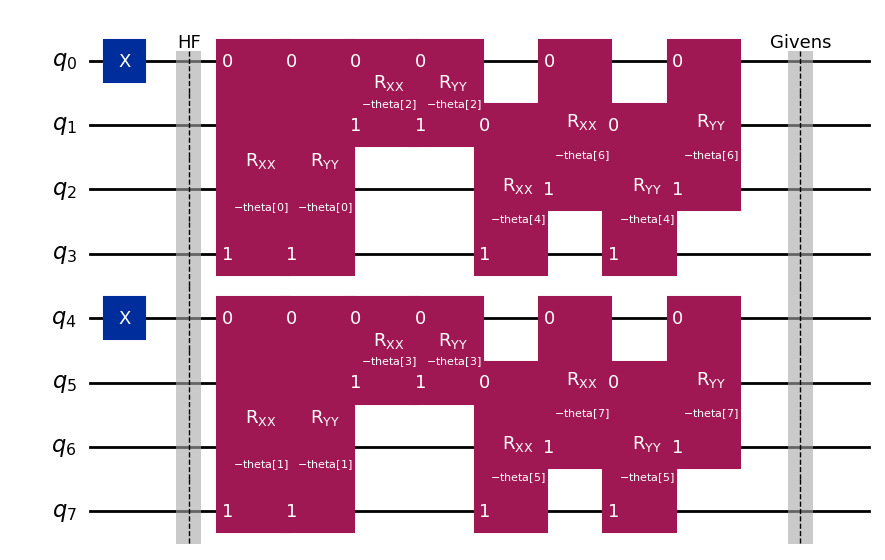

In [3]:
# Redesigned Givens-only schedule
# Added (1,3)/(5,7) mixing to better match GS dominant basis structure.
GIVENS_PAIRS = [(0, 3), (4, 7), (0, 1), (4, 5), (1, 3), (5, 7), (0, 2), (4, 6)]


def givens_block_fermionic(qc: QuantumCircuit, theta, q1: int, q2: int) -> None:
    # Qiskit convention: RXX(a)RYY(a)=exp(-i a/2 (XX+YY)), so use -theta.
    qc.rxx(-theta, q1, q2)
    qc.ryy(-theta, q1, q2)


def prepare_givens_only_circuit() -> tuple[QuantumCircuit, ParameterVector]:
    num_qubits = 8
    qc = QuantumCircuit(num_qubits)

    params = ParameterVector("theta", length=len(GIVENS_PAIRS))

    # HF reference in spin-block ordering.
    qc.x(0)
    qc.x(4)
    qc.barrier(label="HF")

    for i, (q1, q2) in enumerate(GIVENS_PAIRS):
        givens_block_fermionic(qc, params[i], q1, q2)
    qc.barrier(label="Givens")

    return qc, params


ansatz, ansatz_params = prepare_givens_only_circuit()
print(f"Number of parameters: {len(ansatz_params)}")
print("Givens pairs:", GIVENS_PAIRS)
ansatz.draw("mpl")

In [4]:
# Energy and gradient helpers
hamiltonian = H_qubit_loaded
estimator = StatevectorEstimator()
gradient = ParamShiftEstimatorGradient(estimator)


def compute_vqe_energy(params: np.ndarray, circuit: QuantumCircuit, op: SparsePauliOp) -> float:
    pub = (circuit, op, np.asarray(params, dtype=float))
    return float(estimator.run([pub]).result()[0].data.evs)


def compute_vqe_gradient(params: np.ndarray, circuit: QuantumCircuit, op: SparsePauliOp) -> np.ndarray:
    pvals = np.asarray(params, dtype=float)
    grad_result = gradient.run(
        circuits=[circuit],
        observables=[op],
        parameter_values=[pvals],
    ).result()
    return np.asarray(grad_result.gradients[0], dtype=float).reshape(-1)


# smoke test
x_test = np.zeros(len(ansatz_params), dtype=float)
print("Energy at zero params:", compute_vqe_energy(x_test, ansatz, hamiltonian))

Energy at zero params: -7.8619926887407985


In [5]:
# Exact reference
H_dense = hamiltonian.to_matrix(sparse=False)
exact_vals, exact_vecs = np.linalg.eigh(H_dense)
exact_ground_energy = float(np.real_if_close(exact_vals[0]))
exact_ground_state = Statevector(exact_vecs[:, 0])

print("Exact ground-state energy:", exact_ground_energy)

Exact ground-state energy: -7.881653021951597


In [6]:
# Occupancy matching: Givens-only vs exact ground state


def orbital_occupancies_from_statevector(sv: Statevector, n_qubits: int = 8) -> np.ndarray:
    # n_i = probability of qubit i being in |1>.
    occ = np.zeros(n_qubits, dtype=float)
    for i in range(n_qubits):
        occ[i] = float(sv.probabilities([i])[1])
    return occ


def givens_state(params: np.ndarray) -> Statevector:
    circ = ansatz.assign_parameters(np.asarray(params, dtype=float))
    return Statevector.from_instruction(circ)


exact_occ = orbital_occupancies_from_statevector(exact_ground_state, n_qubits=8)

# Initial guess around zero (as requested)
rng = np.random.default_rng(42)
params0 = rng.uniform(-0.05, 0.05, size=len(ansatz_params))
init_sv = givens_state(params0)
init_occ = orbital_occupancies_from_statevector(init_sv, n_qubits=8)

print("Initial Givens params:", params0)
print("\n--- Initial occupancy comparison ---")
print("idx  exact_occ      givens_init    delta")
for i in range(8):
    d = init_occ[i] - exact_occ[i]
    print(f"{i:>2d}   {exact_occ[i]: .10f}   {init_occ[i]: .10f}   {d:+.10f}")


def occupancy_loss(params: np.ndarray) -> float:
    sv = givens_state(params)
    occ = orbital_occupancies_from_statevector(sv, n_qubits=8)
    return float(np.mean((occ - exact_occ) ** 2))


iter_count = [0]


def occupancy_callback(xk):
    iter_count[0] += 1
    loss = occupancy_loss(xk)
    print(f"iter {iter_count[0]:>3d} | occupancy_mse={loss:.12e}")


fit_res = minimize(
    occupancy_loss,
    params0,
    method="Powell",
    callback=occupancy_callback,
    options={"maxiter": 120, "disp": False},
)

fit_sv = givens_state(fit_res.x)
fit_occ = orbital_occupancies_from_statevector(fit_sv, n_qubits=8)

print("\n=== Fit summary (Givens-only occupancy matching) ===")
print("success:", fit_res.success)
print("message:", fit_res.message)
print("iterations:", fit_res.nit)
print("final occupancy mse:", occupancy_loss(fit_res.x))

print("\n--- Final occupancy comparison ---")
print("idx  exact_occ      givens_fit     delta")
for i in range(8):
    d = fit_occ[i] - exact_occ[i]
    print(f"{i:>2d}   {exact_occ[i]: .10f}   {fit_occ[i]: .10f}   {d:+.10f}")

Initial Givens params: [ 0.0273956  -0.00611216  0.03585979  0.0197368  -0.04058227  0.04756224
  0.02611397  0.02860643]

--- Initial occupancy comparison ---
idx  exact_occ      givens_init    delta
 0    0.9764024577    0.9972848623   +0.0208824046
 1    0.0061595608    0.0012835300   -0.0048760308
 2    0.0007698085    0.0006803972   -0.0000894114
 3    0.0166681730    0.0007512105   -0.0159169625
 4    0.9764024577    0.9987554103   +0.0223529526
 5    0.0061595608    0.0003886803   -0.0057708805
 6    0.0007698085    0.0008177555   +0.0000479469
 7    0.0166681730    0.0000381539   -0.0166300191
iter   1 | occupancy_mse=5.203270841827e-07
iter   2 | occupancy_mse=3.563718486625e-08
iter   3 | occupancy_mse=2.432295458989e-09
iter   4 | occupancy_mse=1.692987221443e-10
iter   5 | occupancy_mse=1.134809128667e-11
iter   6 | occupancy_mse=7.792171479158e-13
iter   7 | occupancy_mse=5.362260336849e-14
iter   8 | occupancy_mse=3.688460572074e-15
iter   9 | occupancy_mse=2.509473383340

In [7]:
# Energy of the occupancy-matched Givens-only state
fitted_energy = compute_vqe_energy(fit_res.x, ansatz, hamiltonian)

print("=== Energy of occupancy-matched Givens-only state ===")
print(f"Fitted-state energy:      {fitted_energy:.12f}")
print(f"Exact ground energy:      {exact_ground_energy:.12f}")
print(f"Energy error (fit-exact): {fitted_energy - exact_ground_energy:+.12f}")

=== Energy of occupancy-matched Givens-only state ===
Fitted-state energy:      -7.849461457862
Exact ground energy:      -7.881653021952
Energy error (fit-exact): +0.032191564090


=== Top basis components: Exact GS ===
bitstring      amplitude(real, imag)                 prob
00010001   (+0.98745702, +0.00000000)   0.9750713667
10001000   (-0.11439725, +0.00000000)   0.0130867314
10000010   (+0.05967971, +0.00000000)   0.0035616675
00101000   (-0.05967971, +0.00000000)   0.0035616675
00010010   (-0.03621211, +0.00000000)   0.0013113169
00100001   (+0.03621211, +0.00000000)   0.0013113169
00100010   (-0.03586888, +0.00000000)   0.0012865764
01000100   (-0.02774542, +0.00000000)   0.0007698085
10000001   (+0.00444681, +0.00000000)   0.0000197741
00011000   (-0.00444681, +0.00000000)   0.0000197741
00010011   (-0.00000000, +0.00000000)   0.0000000000
10001010   (+0.00000000, +0.00000000)   0.0000000000
00010100   (-0.00000000, +0.00000000)   0.0000000000
10000000   (-0.00000000, +0.00000000)   0.0000000000
00010101   (-0.00000000, +0.00000000)   0.0000000000
00100000   (-0.00000000, +0.00000000)   0.0000000000

=== Top basis components: Givens-only fitted state ===

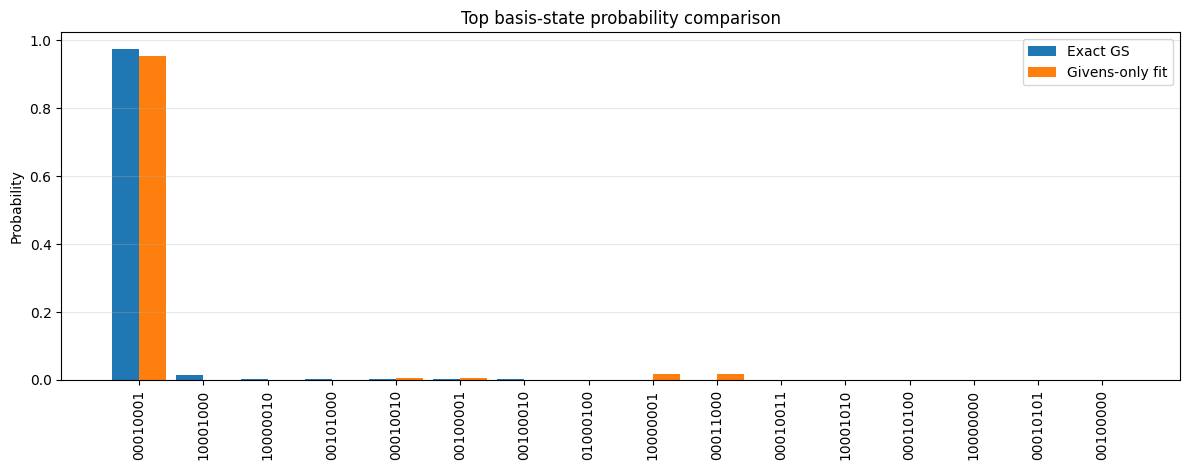

In [8]:
# Print + visualize exact GS vs fitted Givens-only state

def top_components(sv: Statevector, k: int = 16):
    probs = sv.probabilities()
    n = int(np.log2(len(probs)))
    idx = np.argsort(probs)[::-1][:k]
    out = []
    for i in idx:
        amp = sv.data[i]
        bit = format(i, f"0{n}b")
        out.append((bit, amp, float(np.abs(amp) ** 2)))
    return out


top_gs = top_components(exact_ground_state, k=16)
top_fit = top_components(fit_sv, k=16)

print("=== Top basis components: Exact GS ===")
print("bitstring      amplitude(real, imag)                 prob")
for b, a, p in top_gs:
    print(f"{b}   ({a.real:+.8f}, {a.imag:+.8f})   {p:.10f}")

print("\n=== Top basis components: Givens-only fitted state ===")
print("bitstring      amplitude(real, imag)                 prob")
for b, a, p in top_fit:
    print(f"{b}   ({a.real:+.8f}, {a.imag:+.8f})   {p:.10f}")

fidelity_fit_gs = float(state_fidelity(fit_sv, exact_ground_state))
print(f"\nFidelity(fitted, exact GS): {fidelity_fit_gs:.10f}")

# Visualization: compare top probability spectrum side-by-side
labels = [b for b, _, _ in top_gs]
gs_probs = np.array([p for _, _, p in top_gs])
fit_prob_map = {b: p for b, _, p in top_fit}
fit_probs = np.array([fit_prob_map.get(b, 0.0) for b in labels])

x = np.arange(len(labels))
width = 0.42
plt.figure(figsize=(12, 4.8))
plt.bar(x - width / 2, gs_probs, width=width, label="Exact GS")
plt.bar(x + width / 2, fit_probs, width=width, label="Givens-only fit")
plt.xticks(x, labels, rotation=90)
plt.ylabel("Probability")
plt.title("Top basis-state probability comparison")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()